<a href="https://colab.research.google.com/github/GiorgiKarazanashvili/cs666student/blob/main/CS666_Assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

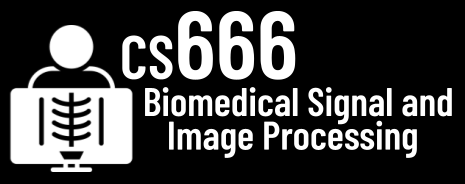
#Assignment 6

In [14]:
# NAME: Giorgi Karazanashvili

In [15]:
# In this assignment, we will visualize and explore a CT scan!

In [16]:
# load numpy and matplotlib
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [17]:
# we are using pydicom, so lets install it!
!pip install pydicom

**Task 1**: Download and visualize data with SliceDrop! [20 Points]

In [18]:
# Use wget to download https://cs666.org/data/ct.zip!
# This is a CT scan of an arm in DICOM format.

In [19]:
!wget https://cs666.org/data/ct.zip

--2026-05-01 16:23:19--  https://cs666.org/data/ct.zip
Resolving cs666.org (cs666.org)... 185.199.110.153, 185.199.111.153, 185.199.108.153, ...
Connecting to cs666.org (cs666.org)|185.199.110.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5847706 (5.6M) [application/x-zip-compressed]
Saving to: ‘ct.zip’

ct.zip              100%[===================>]   5.58M  --.-KB/s    in 0.06s   

2026-05-01 16:23:19 (90.0 MB/s) - ‘ct.zip’ saved [5847706/5847706]



In [20]:
# Then use the following snippet to extract the data.

In [21]:
import zipfile
with zipfile.ZipFile('ct.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

In [22]:
# 1) Let's explore the data using the Files panel on the left.
# TODO: How many slices are there?

In [23]:
# TODO: 220

In [24]:
# 2) Let's visualize the data with SliceDrop!
# Go to https://slicedrop.com and drag'n'drop all .dcm files into the browser.
# Please use the 2D sliders to show axial, sagittal, and coronal slices in 3D.

In [25]:
# TODO Please post a screenshot of SliceDrop's 3D View in the text box below by
# using the Upload image button after double-click. This should not be volume
# rendering but show the 3 cross sections.

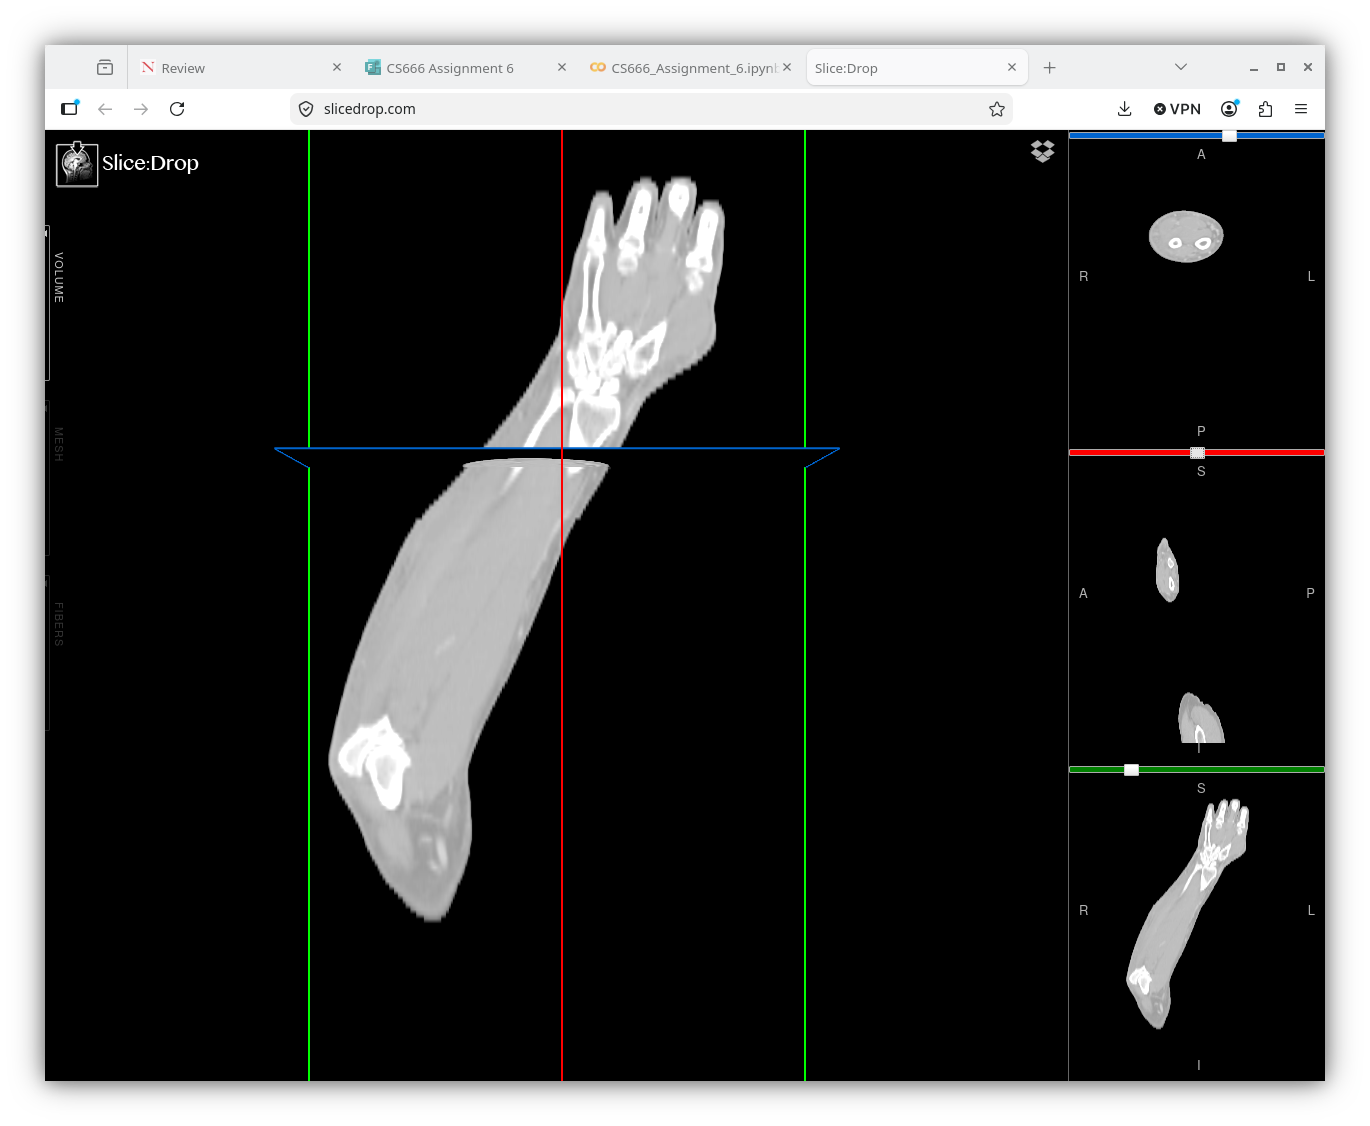

In [26]:
# 3) Let's visualize only the bones! Please use the thresholding
# based on a window suitable for bones and show a 3D volume rendering.

In [27]:
# TODO Please post a screenshot of SliceDrop's 3D View in the text box below by
# using the Upload image button after double-click.

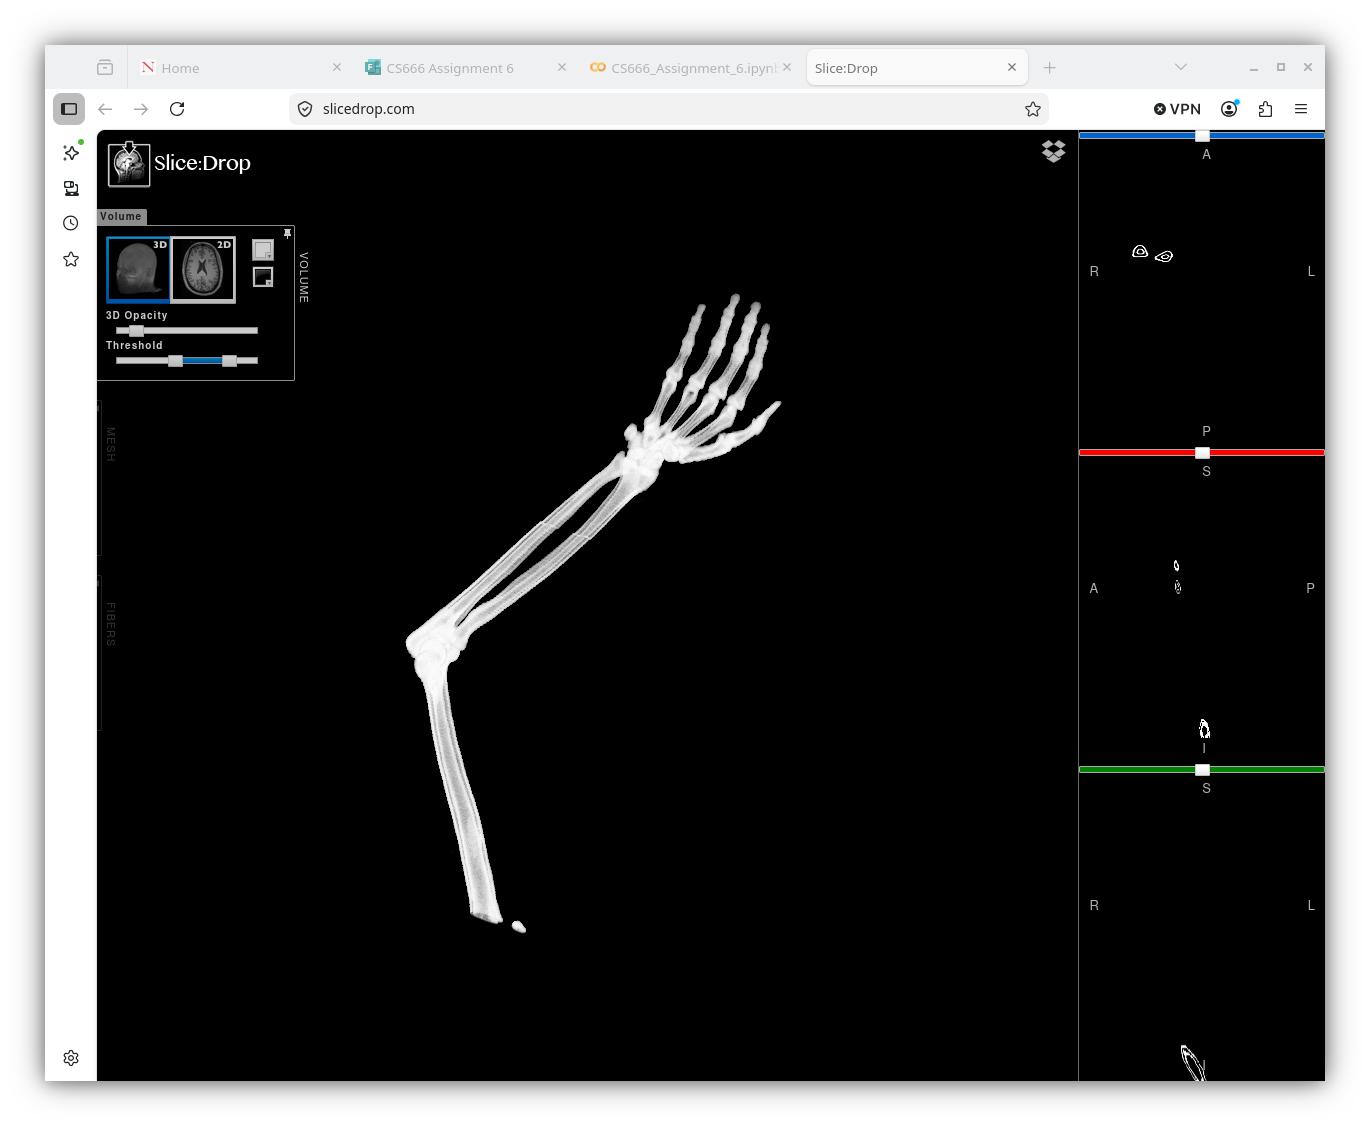

**Task 2**: Load the data using pydicom as a 3D volume and then reslice it! [35 Points]

In [28]:
# 1) Now loop through all the DICOM files and store them in a 3D numpy array.
# Hint: You can either store them in a list first or read the dimensions of a
# single image slice to properly create the 3D numpy array.
# Hint 2: os.listdir(DIR) gives a list of filenames in a directory.
# Hint 2b: This list is not sorted - make sure you sort it.
# Hint 3: The dcmread function loads a single DICOM file.
# Hint 4: You can then use .pixel_array to access the image data.

In [29]:
from pydicom import dcmread
import os

In [30]:
# TODO: YOUR CODE FOR LOADING THE VOLUME AS A 3D NUMPY ARRAY
DIR = 'ct'
files = sorted(os.listdir(DIR))

single = dcmread(os.path.join(DIR, files[0]))
rows, cols = single.pixel_array.shape

volume = np.zeros((len(files), rows, cols))
for i, f in enumerate(files):
    volume[i] = dcmread(os.path.join(DIR, f)).pixel_array

print(volume.shape)

(220, 454, 512)


In [31]:
# 2) Now create and show axial, sagittal, and coronal slices from the 3D volume.
# Hint: Please use imshow(XX, cmap='gray') to show the image.

Text(0.5, 1.0, 'Axial')

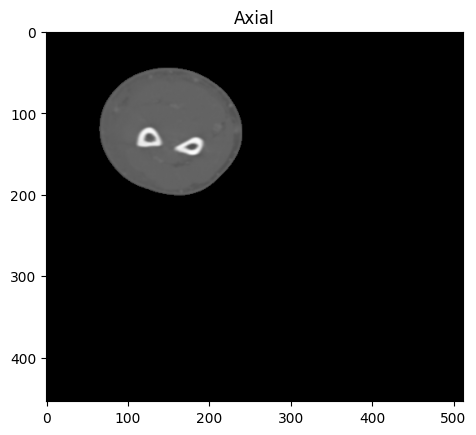

In [63]:
# TODO: YOUR CODE FOR AXIAL
imshow(volume[110], cmap='grey')
plt.title('Axial')

Text(0.5, 1.0, 'Sagittall')

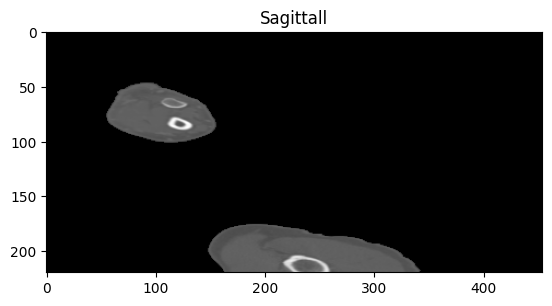

In [70]:
# TODO: YOUR CODE FOR SAGITTAL
imshow(volume[:,:,cols//2], cmap='grey')
plt.title('Sagittall')

Text(0.5, 1.0, 'Coronal')

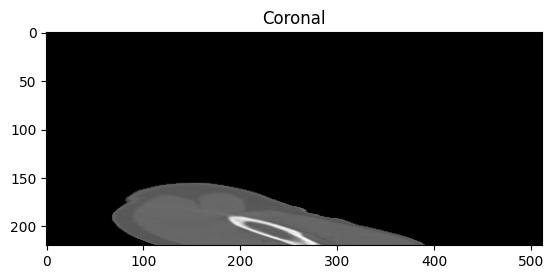

In [69]:
# TODO: YOUR CODE FOR CORONAL
imshow(volume[:,rows//2,:], cmap='grey')
plt.title('Coronal')

**Task 3**: Use the Window/Level-technique to visualize the data! [45 Points]

In [35]:
# We will now enhance the visualization from above by performing
# Window/Level adjustment.
# Here is one way of doing that:
#   vmin = level - window/2
#   vmax = level + window/2
#   plt.imshow(hu_pixels + rescale, cmap='gray', vmin=vmin, vmax=vmax)
#   plt.show()

In [36]:
# 1) Please load the Window/Level values from the DICOM file,
# print these values, and then visualize one slice with window/level adjustment.
# Hint: The DICOM header has the following tags.
#   (0028, 1050) Window Center
#   (0028, 1051) Window Width
# Hint 2: You can use slice[key].value to access DICOM tag values.
# Hint 3: (0028, 1052) Rescale Intercept might be important.

window: 410
level: 30
rescale: -1024


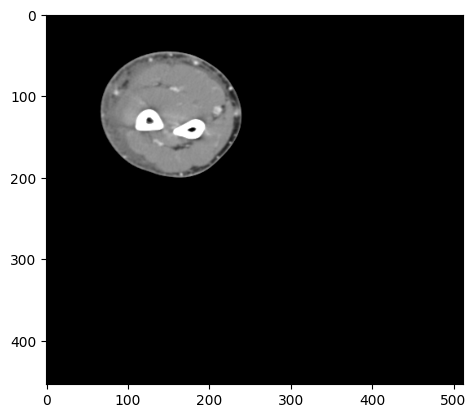

In [75]:
# TODO: YOUR CODE
slice = dcmread(os.path.join(DIR, files[110]))

level = slice[0x0028, 0x1050].value
window = slice[0x0028, 0x1051].value
rescale = slice[0x0028, 0x1052].value

vmin = level - window/2
vmax = level + window/2

imshow(slice.pixel_array + rescale, cmap='grey', vmin=vmin, vmax=vmax)
print(f'window: {window}')
print(f'level: {level}')
print(f'rescale: {rescale}')

In [38]:
# 2) Play around with different Window/Level values that enhance
# the visualization.

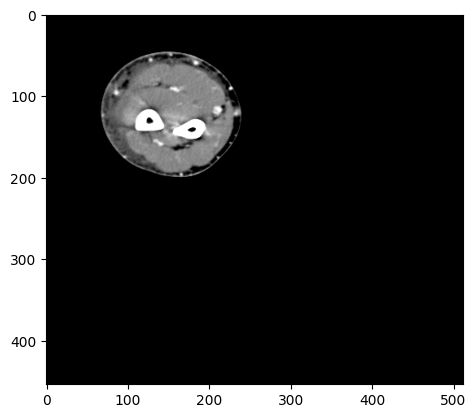

In [94]:
# TODO: YOUR CODE
window = 205
level = 50

vmin = level - window/2
vmax = level + window/2

imshow(slice.pixel_array + rescale, cmap='grey', vmin=vmin, vmax=vmax)

In [40]:
# Which values make sense and why?

I chose to select window = 205 and level = 50
These values make sense to me because 50 is soft tissue value on HU scale (from class slides) and 205 is big enough of a window where we can see and identify different parts of an arm while focusing on the differences between the soft tissues

**Bonus**: Create segmentations (label maps) for the volume using thresholding HU! [33 Points]

In [42]:
# Similar to Window/Level adjustment for visualization, we can threshold
# the volume to highlight the following components using the Hounsfield Units:
# 1) Fat
# 2) Soft Tissue
# 3) Bones
#
# Please create 3 segmentation masks for these structures.
# Then, please visualize each 3 slices per structure to showcase the segmentation.
# Hint: As a reminder, the following code allows thresholding of a numpy array.
#   new_mask = imagevolume.copy()
#   new_mask[new_mask < XXX] = 0
# Hint2: You might need to cast new_mask to int16 not uint16.

In [95]:
volume_hu = volume.astype(uint16)+rescale

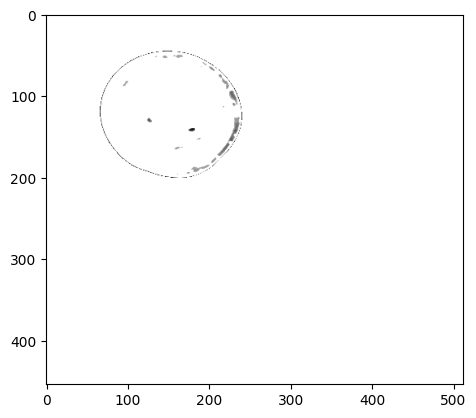

In [108]:
# TODO: YOUR CODE TO SEGMENT FAT
fat = volume_hu.copy()
fat[fat < -200] = 0
fat[fat > -50] = 0
imshow(fat[110], cmap='grey')

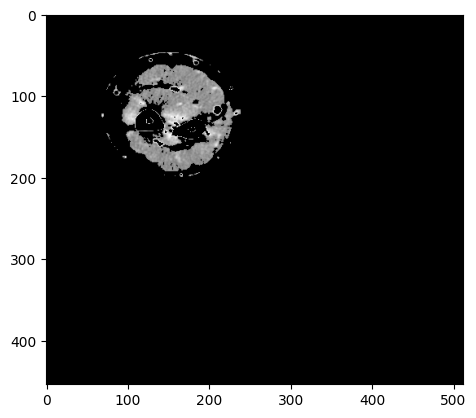

In [143]:
# TODO: YOUR CODE TO SEGMENT SOFT TISSUE
soft = volume_hu.copy()
soft[soft < 50] = 0
soft[soft > 100] = 0
imshow(soft[110], cmap='grey')

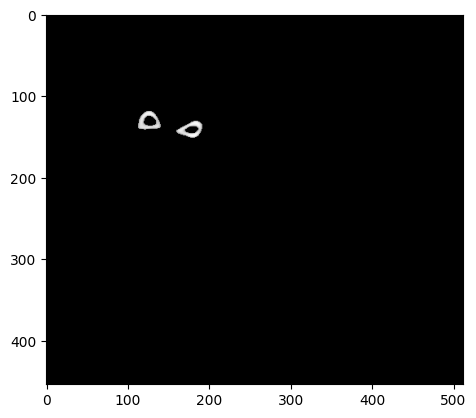

In [148]:
# TODO: YOUR CODE TO SEGMENT BONES
bones = volume_hu.copy()
bones[bones < 1000] = 0 # went down all the way to bones<100 but its the same
                        #segmentation with worse resolution so kept it at <1000
imshow(bones[110], cmap='gray')

In [46]:
# Are the segmentations good?

Fat segmentation is accurate, showing the outer ring

Soft tissue segmentation isolates the muscle tissue well, but you can see
remnants of outlines of bones which didn change even after adjusting the threshold to less than 90

Bone segmentation was the easiest one, you can go as low as 100 or as high up as 1000, the only difference is the reslution, which is why I kept it at 1000

Overall segmentations are good for manual thresholding, it accurately represents the anatomy.

In [48]:
#
# Thank you and Great job!!
#
#                _.---._
#              .'       `.
#              :)       (:
#              \ (@) (@) /
#               \   A   /
#                )     (
#                \"""""/
#                 `._.'
#                  .=.
#          .---._.-.=.-._.---.
#         / ':-(_.-: :-._)-:` \
#        / /' (__.-: :-.__) `\ \
#       / /  (___.-` '-.___)  \ \
#      / /   (___.-'^`-.___)   \ \
#     / /    (___.-'=`-.___)    \ \
#    / /     (____.'=`.____)     \ \
#   / /       (___.'=`.___)       \ \
#  (_.;       `---'.=.`---'       ;._)
#  ;||        __  _.=._  __        ||;
#  ;||       (  `.-.=.-.'  )       ||;
#  ;||       \    `.=.'    /       ||;
#  ;||        \    .=.    /        ||;
#  ;||       .-`.`-._.-'.'-.       ||;
# .:::\      ( ,): O O :(, )      /:::.
# |||| `     / /'`--'--'`\ \     ' ||||
# ''''      / /           \ \      ''''
#          / /             \ \
#         / /               \ \
#        / /                 \ \
#       / /                   \ \
#      / /                     \ \
#     /.'                       `.\
#    (_)'                       `(_)
#     \\.                       .//
#      \\.                     .//
#       \\.                   .//
#        \\.                 .//
#         \\.               .//
#          \\.             .//
#     jgs   \\.           .//
#           ///)         (\\\
#         ,///'           `\\\,
#        ///'               `\\\
#       ""'                   '""